In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [35]:
titanic = sns.load_dataset("titanic")

In [36]:
titanic.head()
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [37]:
features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

In [38]:
# missing data
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [39]:
titanic.head()
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [40]:
# encoding data
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [41]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [42]:
X = titanic[features]
y = titanic[target]

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [44]:
X_train.head()

,pclass,sex,fare,embarked,age
445,1,1,81.8583,2,4.0
650,3,1,7.8958,2,28.0
172,3,0,11.1333,2,1.0
450,2,1,27.7500,2,36.0
314,2,1,26.2500,2,43.0


In [45]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

DecisionTreeClassifier()

In [46]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy Score : ", accuracy_score(y_test, y_pred))

Accuracy Score :  0.7649253731343284


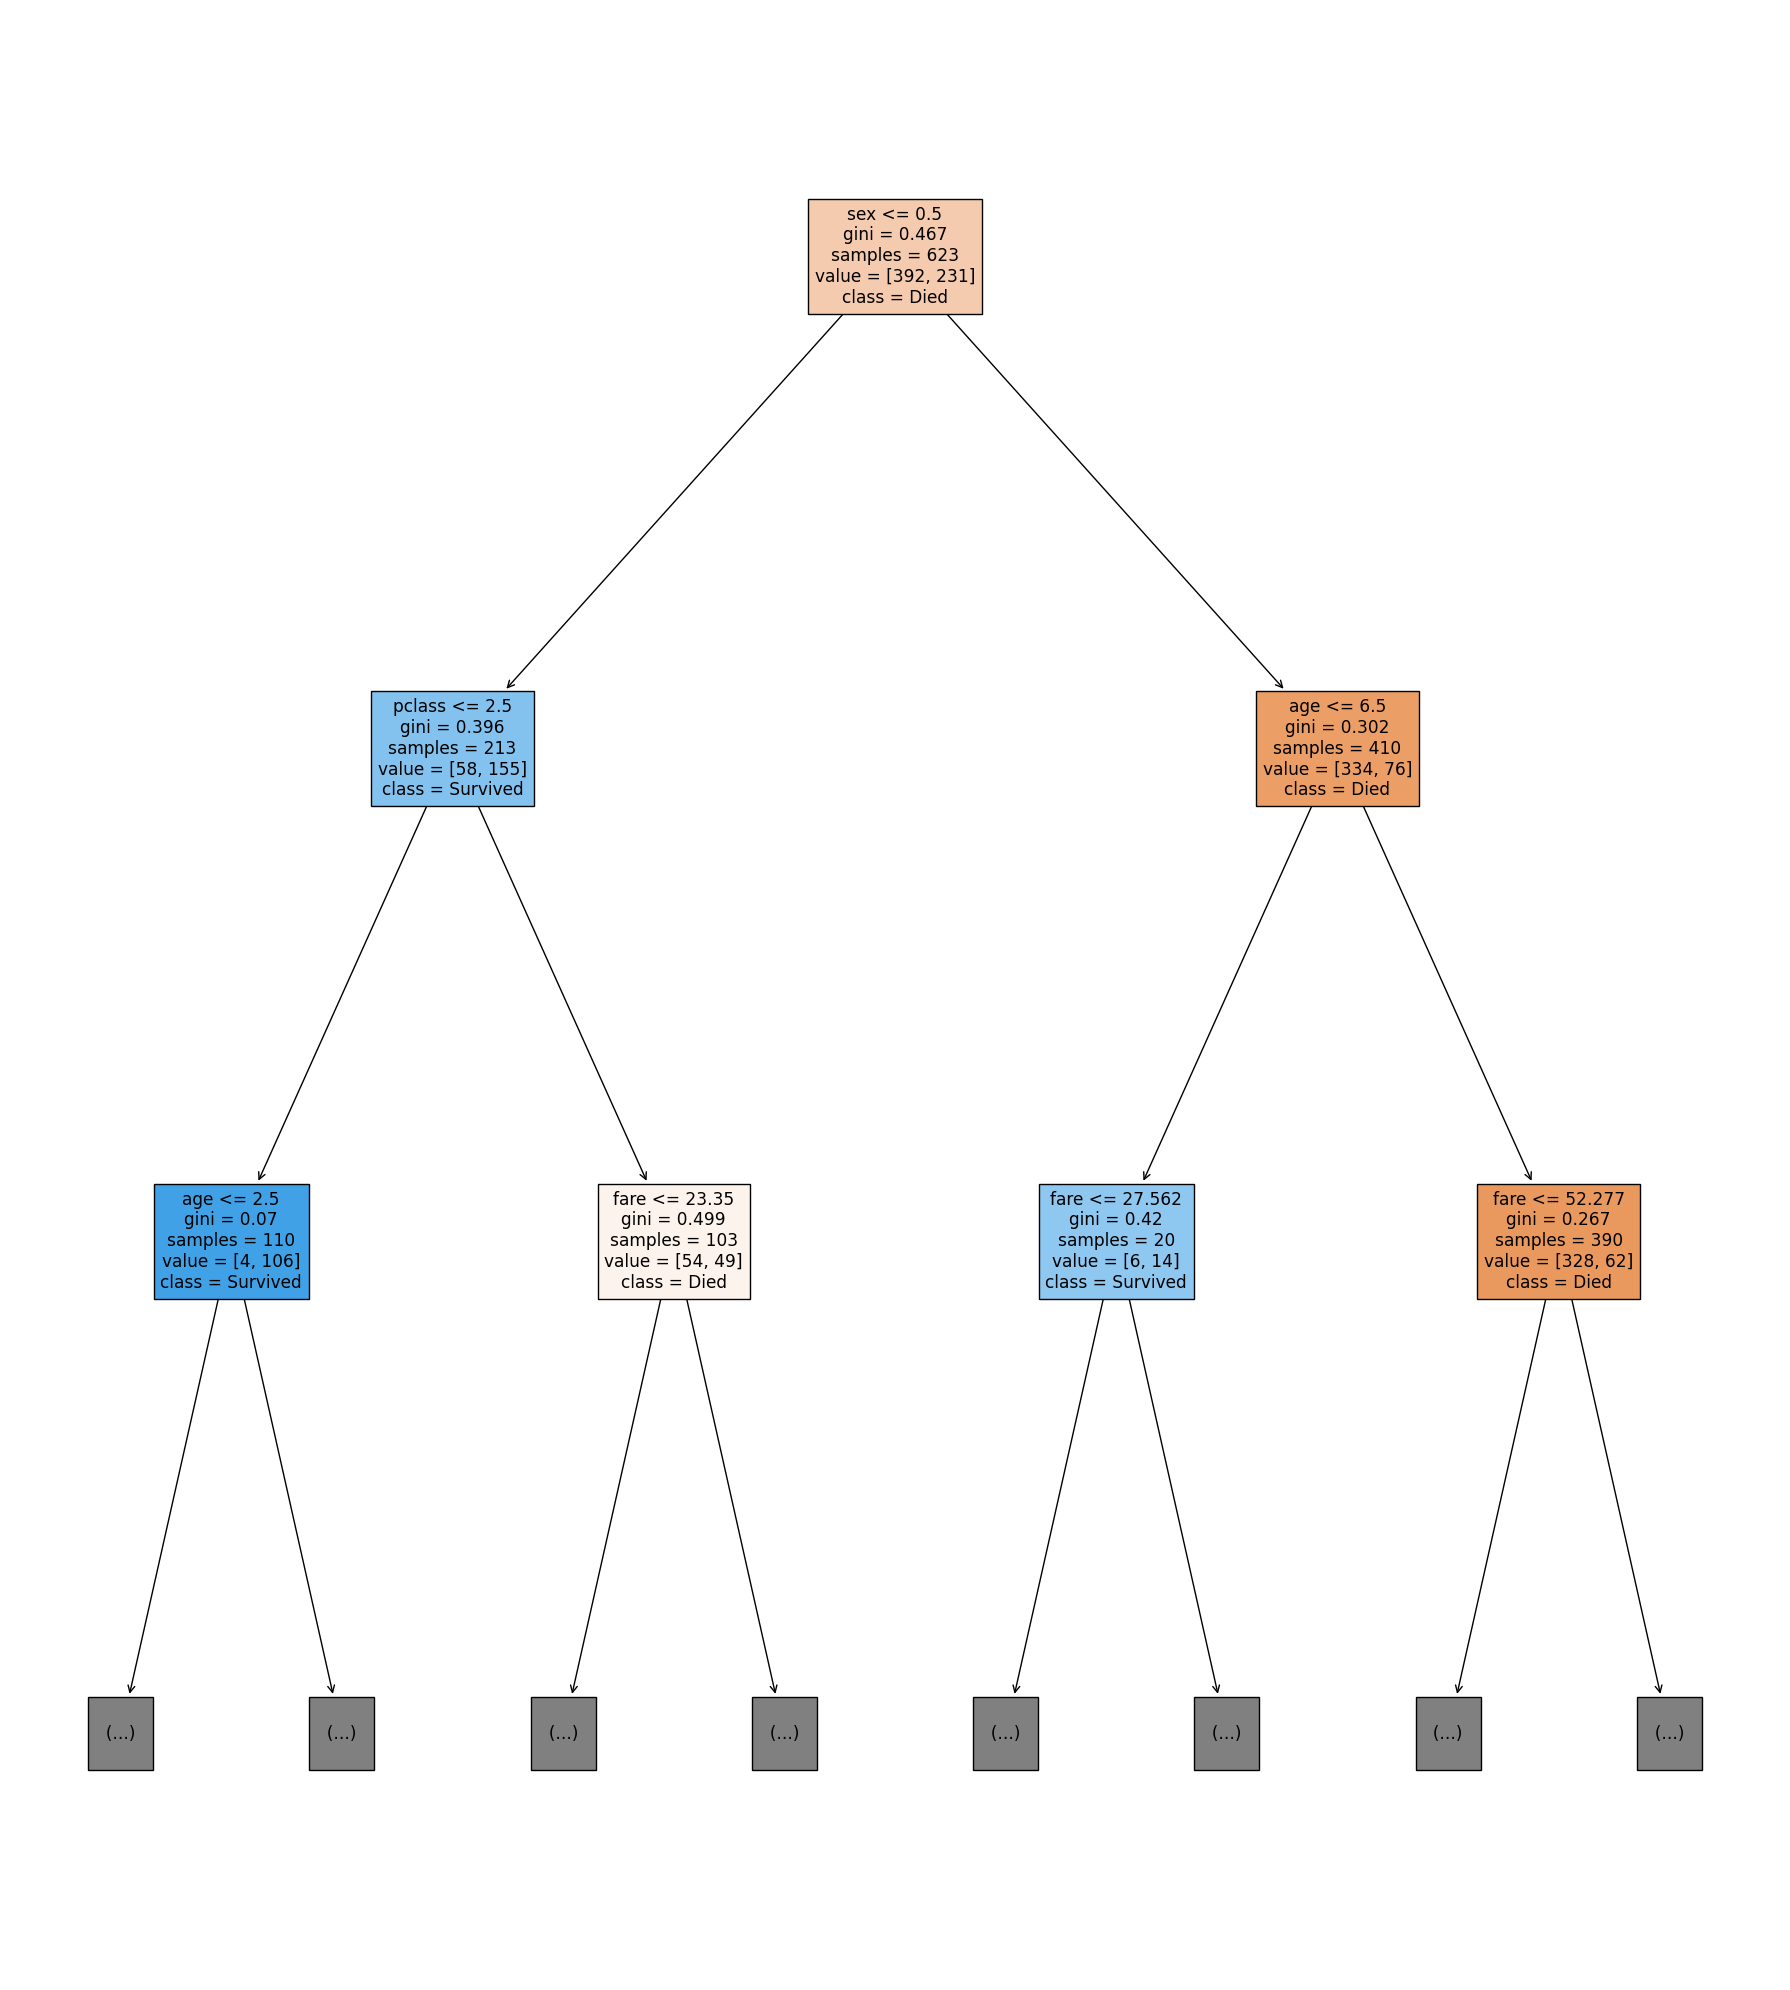

In [47]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 20))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    max_depth=2,
)

plt.tight_layout()
plt.show()

## Decision Tree With Pre-Pruning


for depth 2 accuracy : 0.7723880597014925
for depth 3 accuracy : 0.8059701492537313
for depth 4 accuracy : 0.8246268656716418


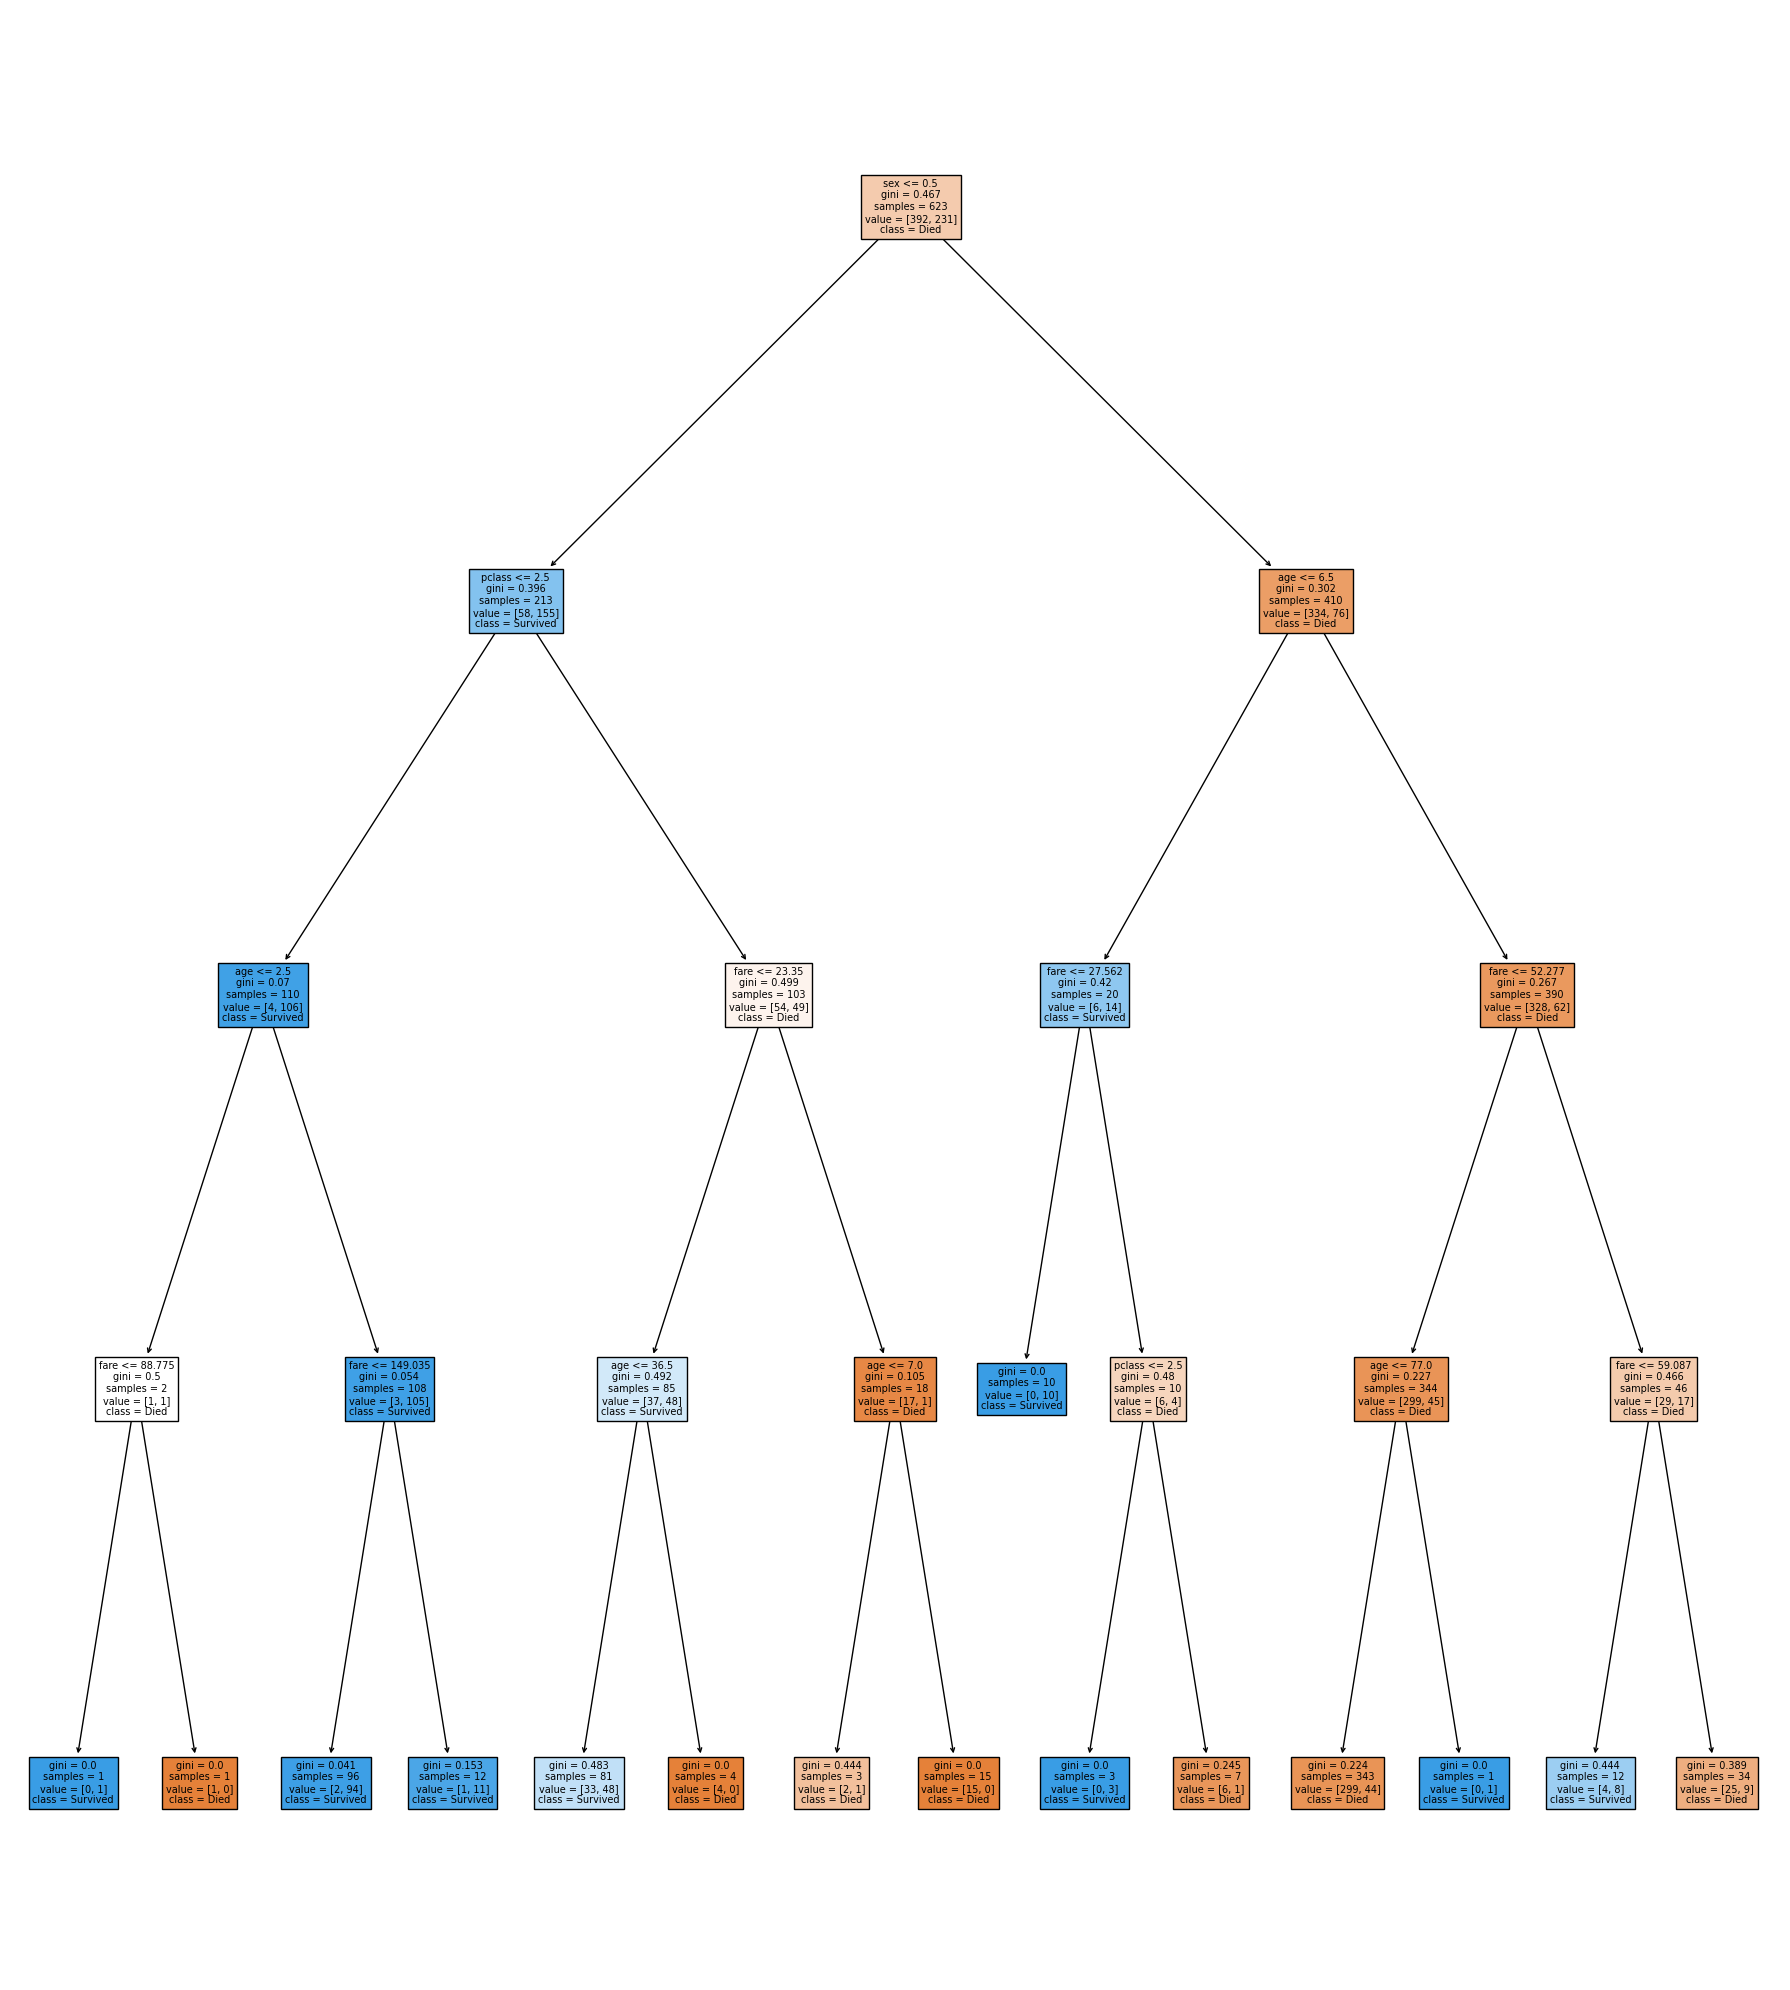

for depth 5 accuracy : 0.7947761194029851
for depth 6 accuracy : 0.7873134328358209
for depth 7 accuracy : 0.7873134328358209
for depth 8 accuracy : 0.7947761194029851
for depth 9 accuracy : 0.7723880597014925
for depth 10 accuracy : 0.7873134328358209


In [48]:
# Decision Tree with Pruning
max_depth = [2, 3, 4, 5, 6, 7, 8, 9, 10]
for depth in max_depth:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"for depth {depth} accuracy : {acc}")
    if depth == 4:
        plt.figure(figsize=(18, 20))

        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died", "Survived"],
            filled=True,
        )

        plt.tight_layout()
        plt.show()

for split 10 accuracy : 0.8246268656716418


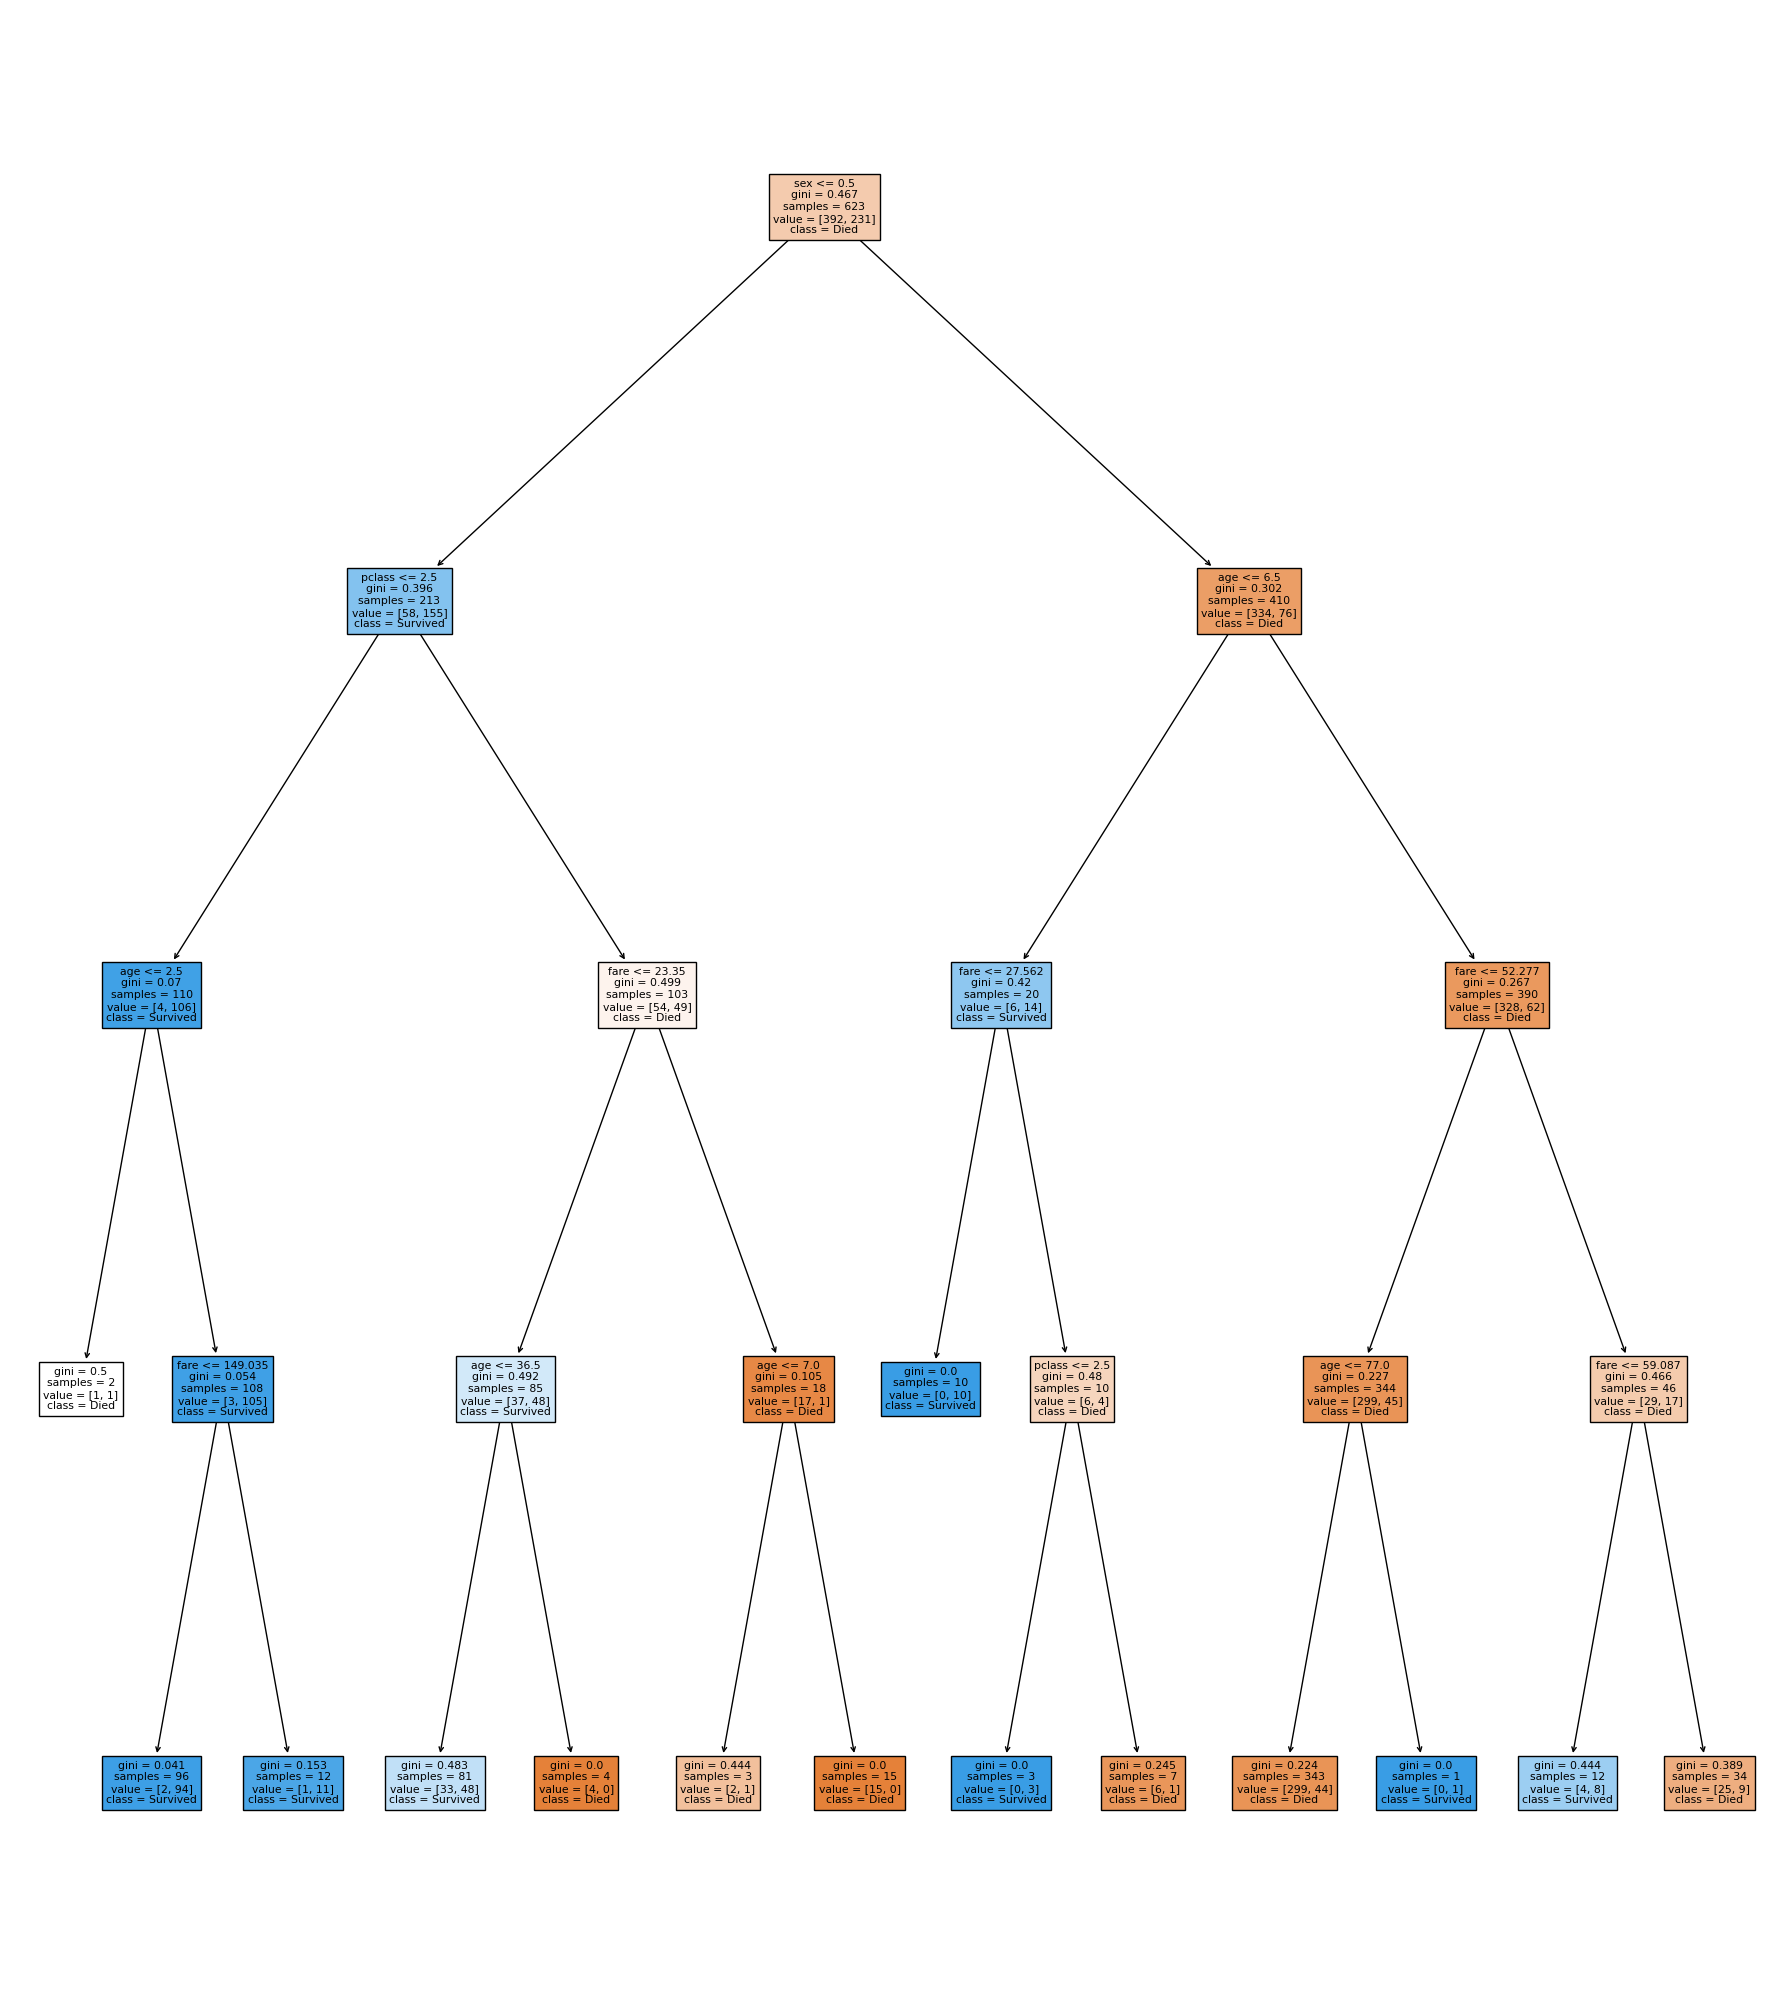

for split 15 accuracy : 0.8171641791044776
for split 20 accuracy : 0.8171641791044776
for split 25 accuracy : 0.8208955223880597
for split 30 accuracy : 0.8208955223880597


In [49]:
# Decision Tree with Pruning
min_sample_split = [10, 15, 20, 25, 30]
for split in min_sample_split:
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"for split {split} accuracy : {acc}")
    if split == 10:
        plt.figure(figsize=(18, 20))

        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died", "Survived"],
            filled=True,
        )

        plt.tight_layout()
        plt.show()

## Decision Tree With Post-Pruning


In [50]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [51]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.         0.00013376 0.00013376 0.00022931 0.00032103
 0.00048409 0.00053505 0.00053505 0.00053505 0.00062746 0.00064205
 0.00077709 0.00085607 0.00093633 0.00096308 0.00096308 0.00096308
 0.00099875 0.00101659 0.00104193 0.0010478  0.00107009 0.00109238
 0.00115927 0.0012352  0.00123729 0.00129646 0.00132211 0.00133563
 0.00137583 0.00137583 0.00139708 0.00143228 0.00144145 0.00150482
 0.00151596 0.00152184 0.00171215 0.00183444 0.0019012  0.00195674
 0.00200642 0.00214018 0.00233474 0.0024077  0.00260835 0.00263292
 0.00278606 0.00280169 0.00284379 0.00288925 0.00299625 0.00302412
 0.00431144 0.00495299 0.00577849 0.00589431 0.0074248  0.01236198
 0.01787674 0.04065074 0.1323581 ]


In [54]:
# train model for all alphas
trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    trees.append((model, alpha))

In [55]:
best_acc = 0
best_alpha = 0
for model, alpha in trees:
    curr_accuracy = model.score(X_test, y_test)
    if curr_accuracy > best_acc:
        best_acc = curr_accuracy
        best_alpha = alpha

In [56]:
best_acc

0.8208955223880597

In [59]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.0017121455323702516)

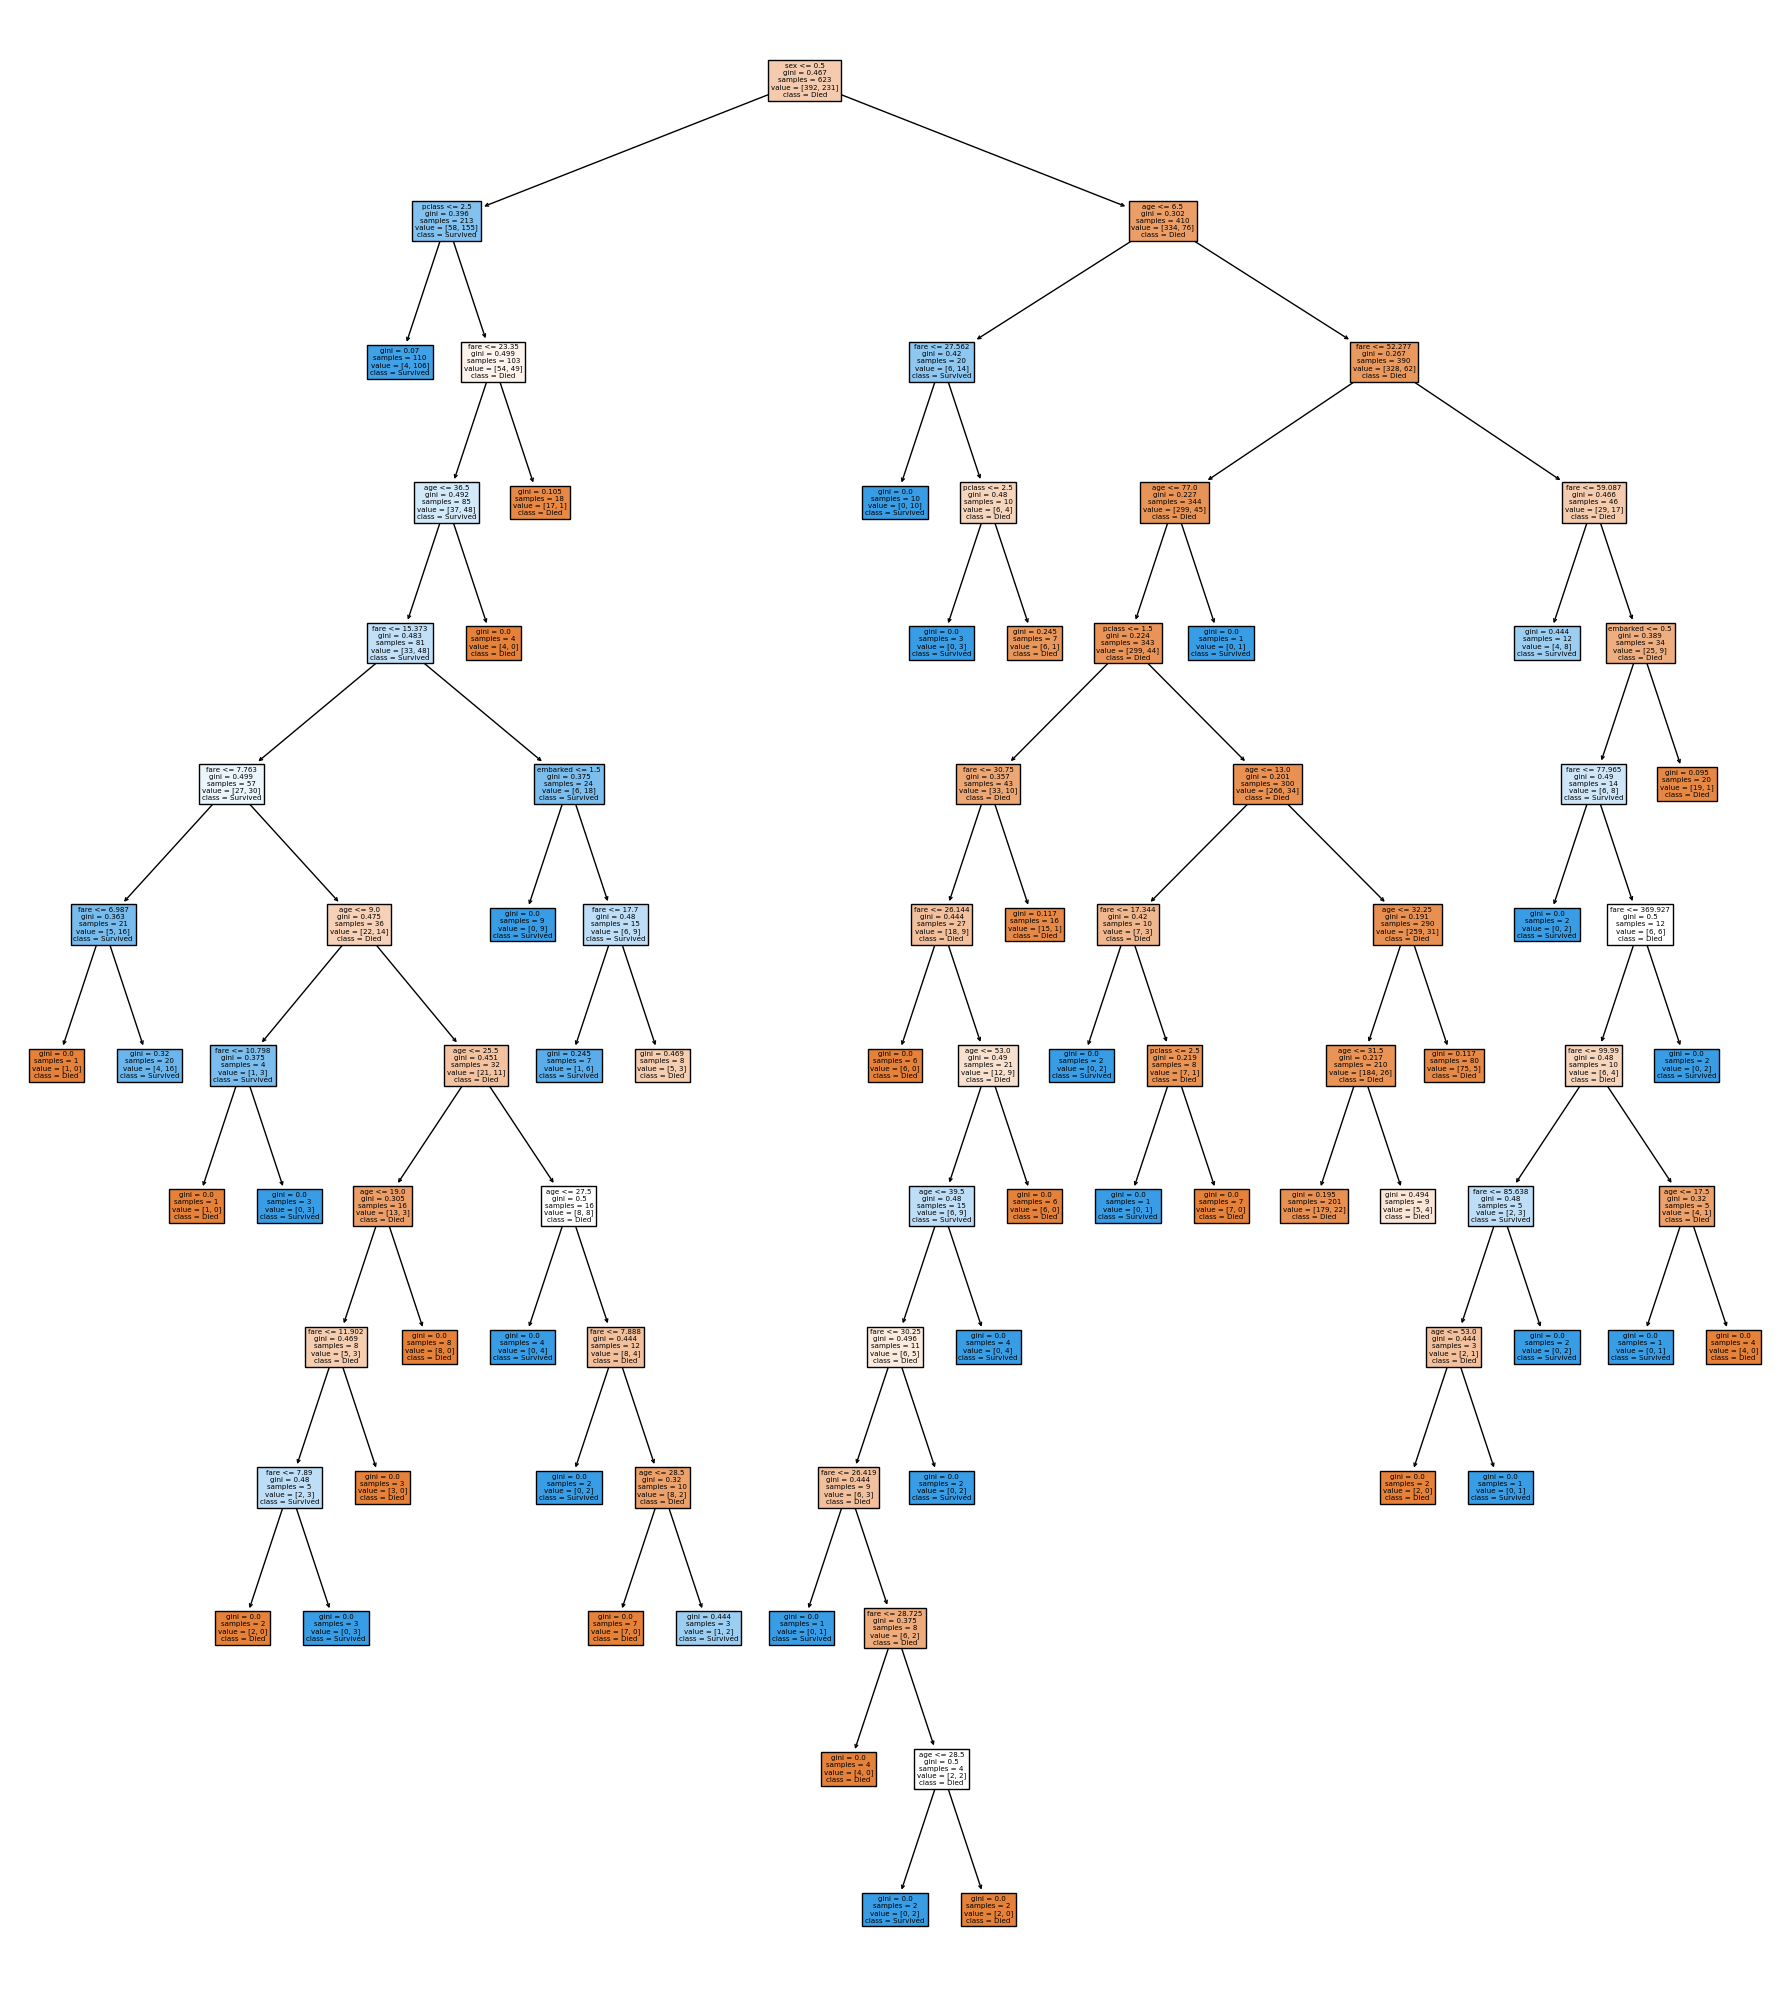

In [62]:
plt.figure(figsize=(18, 20))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
)

plt.tight_layout()
plt.show()

In [61]:
print(best_model.score(X_test, y_test))

0.8208955223880597
